In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 1: Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time
import os

In [3]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Cell 2: Paths & save dir
train_path = '/content/drive/MyDrive/RetinalOCT_Dataset/RetinalOCT_Dataset/train'
val_path   = '/content/drive/MyDrive/RetinalOCT_Dataset/RetinalOCT_Dataset/val'

save_dir = "results"
os.makedirs(save_dir, exist_ok=True)
model_save_path = os.path.join(save_dir, "best_model_resnet_cbam.pth")


In [5]:
# Cell 3: Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(40),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [6]:
# Cell 4: Datasets and loaders
dataset_train = datasets.ImageFolder(root=train_path, transform=transform)
dataset_val   = datasets.ImageFolder(val_path, transform=val_transform)

class_names = dataset_train.classes
print(f"Classes: {class_names}")
print(f"Train size: {len(dataset_train)}, Val size: {len(dataset_val)}")

train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(dataset_val, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Classes: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']
Train size: 18412, Val size: 2802


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [7]:

# Cell 5: CBAM implementation (Channel + Spatial attention)
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, kernel_size=1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        assert kernel_size in (3, 7), "kernel size must be 3 or 7"
        padding = 3 if kernel_size == 7 else 1
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # along channel axis: avg and max
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        cat = torch.cat([avg_out, max_out], dim=1)  # (B,2,H,W)
        out = self.conv(cat)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size=spatial_kernel)

    def forward(self, x):
        # Channel attention
        ca = self.channel_att(x)
        x = x * ca
        # Spatial attention
        sa = self.spatial_att(x)
        x = x * sa
        return x

In [8]:
# Cell 6: Load ResNet50 and attach CBAM after each stage
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)  # pretrained

resnet.layer1 = nn.Sequential(resnet.layer1, CBAM(channels=256, reduction=16))
resnet.layer2 = nn.Sequential(resnet.layer2, CBAM(channels=512, reduction=16))
resnet.layer3 = nn.Sequential(resnet.layer3, CBAM(channels=1024, reduction=16))
resnet.layer4 = nn.Sequential(resnet.layer4, CBAM(channels=2048, reduction=16))

# Replace final FC head for your number of classes
num_classes = len(class_names)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)

model = resnet.to(device)
print(f"Model: ResNet50 + CBAM with {num_classes} output classes")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]


Model: ResNet50 + CBAM with 8 output classes


In [9]:
# Cell 7: Utilities and fixed helpers (AverageMeter, plotting, training, evaluation)
class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    plt.figure(figsize=(15, 5))
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Training and Validation Loss'); plt.legend(); plt.grid(True)
    # Acc
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_curves_resnet_cbam.png'))
    plt.show()

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10, 8))
    cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Normalized Confusion Matrix'); plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45); plt.yticks(tick_marks, class_names)
    fmt = '.2f'; thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix_resnet_cbam.png'))
    plt.show()

In [10]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=40, patience=10):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_acc = 0.0
    early_stop_counter = 0

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_meter = AverageMeter()
        train_acc_meter  = AverageMeter()

        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for images, labels in train_loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            acc = torch.sum(preds == labels).item() / labels.size(0)
            train_loss_meter.update(loss.item(), images.size(0))
            train_acc_meter.update(acc, images.size(0))
            train_loop.set_postfix(loss=train_loss_meter.avg, acc=train_acc_meter.avg)

        # Validation
        model.eval()
        val_loss_meter = AverageMeter()
        val_acc_meter  = AverageMeter()
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]")
        with torch.no_grad():
            for images, labels in val_loop:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                acc = torch.sum(preds == labels).item() / labels.size(0)
                val_loss_meter.update(loss.item(), images.size(0))
                val_acc_meter.update(acc, images.size(0))
                val_loop.set_postfix(loss=val_loss_meter.avg, acc=val_acc_meter.avg)

        if scheduler is not None:
            scheduler.step(val_loss_meter.avg)

        train_losses.append(train_loss_meter.avg)
        val_losses.append(val_loss_meter.avg)
        train_accs.append(train_acc_meter.avg)
        val_accs.append(val_acc_meter.avg)

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} completed in {epoch_time:.2f}s")
        print(f"Train Loss: {train_loss_meter.avg:.4f}, Train Acc: {train_acc_meter.avg:.4f}")
        print(f"Val Loss: {val_loss_meter.avg:.4f}, Val Acc: {val_acc_meter.avg:.4f}")

        if val_acc_meter.avg > best_val_acc:
            best_val_acc = val_acc_meter.avg
            torch.save(model.state_dict(), model_save_path)
            print(f"Saved best model with validation accuracy: {best_val_acc:.4f}")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f"Validation accuracy did not improve. Early stopping counter: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

        print("-" * 60)

    # Load best model
    if os.path.exists(model_save_path):
        model.load_state_dict(torch.load(model_save_path, map_location=device))

    # Plot curves
    plot_training_curves(train_losses, val_losses, train_accs, val_accs)
    return model, train_losses, val_losses, train_accs, val_accs

In [11]:
# Cell 8: Optimizer / Scheduler / Criterion
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Starting ResNet50+CBAM training...


Epoch 1/5 [Valid]: 100%|██████████| 88/88 [04:03<00:00,  2.76s/it, acc=0.955, loss=0.133]


Epoch 1/5 completed in 1706.58s
Train Loss: 0.3029, Train Acc: 0.9044
Val Loss: 0.1332, Val Acc: 0.9547
Saved best model with validation accuracy: 0.9547
------------------------------------------------------------


Epoch 2/5 [Valid]: 100%|██████████| 88/88 [00:23<00:00,  3.75it/s, acc=0.958, loss=0.124]


Epoch 2/5 completed in 257.15s
Train Loss: 0.1526, Train Acc: 0.9508
Val Loss: 0.1243, Val Acc: 0.9582
Saved best model with validation accuracy: 0.9582
------------------------------------------------------------


...

Epoch 3/5 completed in 257.65s
Train Loss: 0.1289, Train Acc: 0.9578
Val Loss: 0.1125, Val Acc: 0.9625
Saved best model with validation accuracy: 0.9625
------------------------------------------------------------


Epoch 4/5 [Valid]: 100%|██████████| 88/88 [00:24<00:00,  3.64it/s, acc=0.963, loss=0.105]


Epoch 4/5 completed in 257.53s
Train Loss: 0.1186, Train Acc: 0.9605
Val Loss: 0.1048, Val Acc: 0.9632
Saved best model with validation accuracy: 0.9632
------------------------------------------------------------


Epoch 5/5 [Valid]: 100%|██████████| 88/88 [00:24<00:00,  3.64it/s, acc=0.959, loss=0.109]


Epoch 5/5 completed in 258.16s
Train Loss: 0.1106, Train Acc: 0.9644
Val Loss: 0.1090, Val Acc: 0.9590
Validation accuracy did not improve. Early stopping counter: 1/10
------------------------------------------------------------


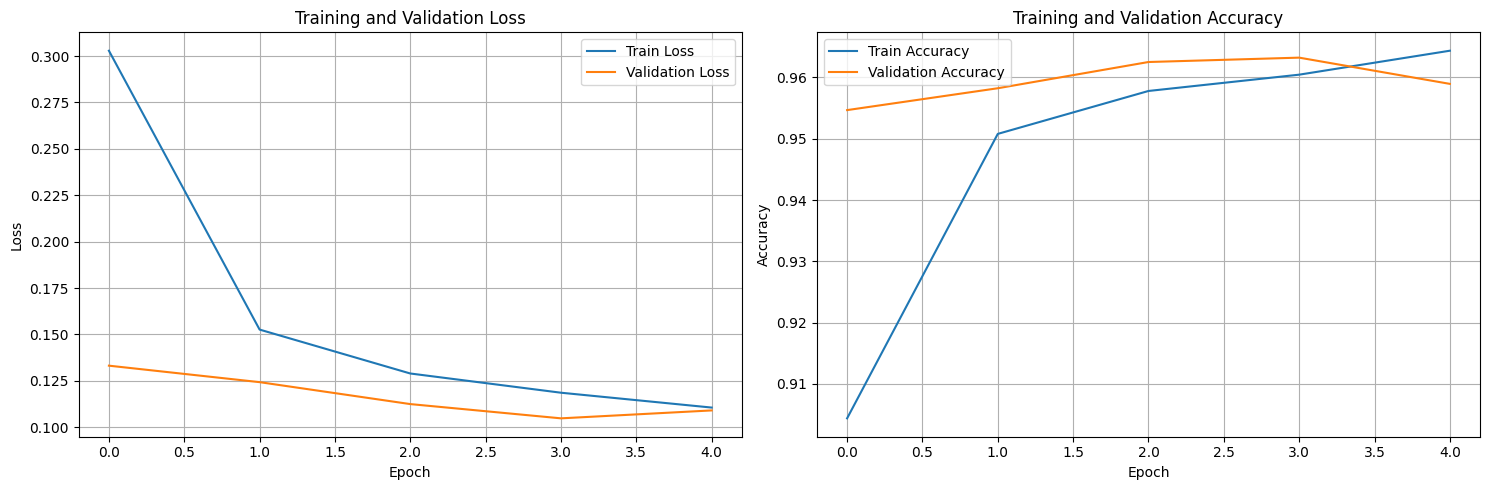

In [12]:
# Cell 9: Train (short run example; change epochs as needed)
print("Starting ResNet50+CBAM training...")
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=5,
    patience=10
)

In [16]:
torch.save(model.state_dict(), model_save_path)

In [17]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names (VERY IMPORTANT – same order as training)
class_names = ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']
num_classes = len(class_names)

In [22]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(
            self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x))
        )

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size=spatial_kernel)

    def forward(self, x):
        x = x * self.channel_att(x)
        x = x * self.spatial_att(x)
        return x

In [23]:
def load_model(model_path):
    resnet = models.resnet50(weights=None)

    # SAME CBAM PLACEMENT AS TRAINING
    resnet.layer1 = nn.Sequential(resnet.layer1, CBAM(256))
    resnet.layer2 = nn.Sequential(resnet.layer2, CBAM(512))
    resnet.layer3 = nn.Sequential(resnet.layer3, CBAM(1024))
    resnet.layer4 = nn.Sequential(resnet.layer4, CBAM(2048))

    # FC layer
    resnet.fc = nn.Linear(resnet.fc.in_features, 8)

    # LOAD WEIGHTS
    state_dict = torch.load(model_path, map_location=device)
    resnet.load_state_dict(state_dict, strict=True)

    resnet.to(device)
    resnet.eval()
    return resnet


model_path = "/content/results/best_model_resnet_cbam.pth"
model = load_model(model_path)

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [24]:
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [25]:
def predict_image(image_path, model):
    image = Image.open(image_path).convert("RGB")
    image = infer_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probs, dim=1)

    predicted_class = class_names[pred_idx.item()]
    confidence = confidence.item() * 100

    return predicted_class, confidence

In [27]:
image_path = "/content/drive/MyDrive/RetinalOCT_Dataset/RetinalOCT_Dataset/train/CNV/cnv_train_1001.jpg"  # <-- your OCT image
pred_class, conf = predict_image(image_path, model)

print(f"🧠 Predicted Class: {pred_class}")
print(f"📊 Confidence: {conf:.2f}%")


🧠 Predicted Class: CNV
📊 Confidence: 96.84%


In [28]:
image_path = "/content/drive/MyDrive/RetinalOCT_Dataset/RetinalOCT_Dataset/train/DR/dr_train_1001.jpg"  # <-- your OCT image
pred_class, conf = predict_image(image_path, model)

print(f"🧠 Predicted Class: {pred_class}")
print(f"📊 Confidence: {conf:.2f}%")


🧠 Predicted Class: DR
📊 Confidence: 100.00%


In [29]:
image_path = "/content/drive/MyDrive/RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1001.jpg"  # <-- your OCT image
pred_class, conf = predict_image(image_path, model)

print(f"🧠 Predicted Class: {pred_class}")
print(f"📊 Confidence: {conf:.2f}%")


🧠 Predicted Class: NORMAL
📊 Confidence: 96.54%


#testing

In [39]:
import json

class_map_path = os.path.join(save_dir, "class_names.json")
with open(class_map_path, "w") as f:
    json.dump(class_names, f)

print("Class names saved:", class_names)

Class names saved: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']


In [38]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision import models
import torch.nn.functional as F
import os
from tqdm import tqdm
import json

In [40]:
# Path to trained model
MODEL_PATH = "results/best_model_resnet_cbam.pth"
CLASS_NAMES_PATH = "results/class_names.json"

# New TEST dataset (can contain unseen classes)
TEST_PATH = "/content/drive/MyDrive/test"


In [44]:
with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

num_classes = len(class_names)
print("Trained classes:", class_names)

Trained classes: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']


In [45]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(
            self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x))
        )


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg, max_], dim=1)
        return self.sigmoid(self.conv(x))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size=spatial_kernel)

    def forward(self, x):
        x = x * self.channel_att(x)
        x = x * self.spatial_att(x)
        return x


In [46]:
model = models.resnet50(weights=None)

model.layer1 = nn.Sequential(model.layer1, CBAM(256))
model.layer2 = nn.Sequential(model.layer2, CBAM(512))
model.layer3 = nn.Sequential(model.layer3, CBAM(1024))
model.layer4 = nn.Sequential(model.layer4, CBAM(2048))

model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [47]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [48]:
test_dataset = datasets.ImageFolder(TEST_PATH, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Test classes (actual folders):", test_dataset.classes)
print("Total test images:", len(test_dataset))

Test classes (actual folders): ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID']
Total test images: 2068


In [49]:
def open_set_predict(outputs, threshold=0.6):
    probs = F.softmax(outputs, dim=1)
    max_prob, pred_idx = torch.max(probs, dim=1)

    if max_prob.item() < threshold:
        return "UNKNOWN", max_prob.item()
    else:
        return class_names[pred_idx.item()], max_prob.item()

In [50]:
threshold = 0.9

results = []

for images, labels in tqdm(test_loader, desc="Testing"):
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)

    pred_label, confidence = open_set_predict(outputs, threshold)

    true_label = test_dataset.classes[labels.item()]

    results.append({
        "True_Label": true_label,
        "Predicted_Label": pred_label,
        "Confidence": round(confidence, 3)
    })


Testing: 100%|██████████| 2068/2068 [07:15<00:00,  4.75it/s]


In [ ]:
total = len(results)
correct = sum(
    1 for r in results
    if r["True_Label"] == r["Predicted_Label"]
)
            

overall_accuracy = correct / total

print(f"Testing Accuracy: {overall_accuracy}")

Overall Testing Accuracy: 99.95744680851064


In [63]:
image_path = "/content/rao_1379599_1.jpg"  # <-- your OCT image
pred_class, conf = predict_image(image_path, model)


if conf>90:
  print(f"🧠 Predicted Class: {pred_class}")
  print(f"📊 Confidence: {conf:.2f}%")
else:
  print('Unknown Class')


Unknown Class


In [64]:
image_path = "/content/erm_2166457_1.jpg"  # <-- your OCT image
pred_class, conf = predict_image(image_path, model)


if conf>90:
  print(f"🧠 Predicted Class: {pred_class}")
  print(f"📊 Confidence: {conf:.2f}%")
else:
  print('Unknown Class')


Unknown Class


In [65]:
image_path = "/content/no_7647664_2.jpg"  # <-- your OCT image
pred_class, conf = predict_image(image_path, model)


if conf>90:
  print(f"🧠 Predicted Class: {pred_class}")
  print(f"📊 Confidence: {conf:.2f}%")
else:
  print('Unknown Class')

🧠 Predicted Class: NORMAL
📊 Confidence: 93.77%
